In [ ]:
# Расчет коэффициента пролонгации клиентов по отделам и менеджерам

## Цель проекта

Цель проекта - рассчитать коэффициенты пролонгации по каждому менеджеру и по всему отделу за год.
Проект выполнен в формате аналитического исследования с использованием Python, pandas и Jupyter Notebook.

In [ ]:
## Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import locale
import matplotlib.pyplot as plt

try:
    locale.setlocale(locale.LC_TIME, 'Russian_Russia.1251')
except:
   
    locale.setlocale(locale.LC_TIME, 'ru_RU.UTF-8')


In [ ]:
## Загрузка financial_data.csv

In [2]:
file_id = "1kSg3Ln2L7KyWk2ccniphlsqDuBZD4ytQ"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

financial_data = pd.read_csv(url, sep=",", encoding="utf-8-sig")
financial_data.head()

,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
0,42,NaN,"36 220,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
1,657,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
3,594,NaN,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
4,665,NaN,"10 000,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович


In [3]:
## Проверка качества данных (пустые строки, дубликаты, проверка типов)

financial_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             451 non-null    int64
 1   Причина дубля  301 non-null    str  
 2   Ноябрь 2022    156 non-null    str  
 3   Декабрь 2022   159 non-null    str  
 4   Январь 2023    139 non-null    str  
 5   Февраль 2023   145 non-null    str  
 6   Март 2023      168 non-null    str  
 7   Апрель 2023    174 non-null    str  
 8   Май 2023       190 non-null    str  
 9   Июнь 2023      190 non-null    str  
 10  Июль 2023      195 non-null    str  
 11  Август 2023    199 non-null    str  
 12  Сентябрь 2023  186 non-null    str  
 13  Октябрь 2023   182 non-null    str  
 14  Ноябрь 2023    171 non-null    str  
 15  Декабрь 2023   146 non-null    str  
 16  Январь 2024    95 non-null     str  
 17  Февраль 2024   101 non-null    str  
 18  Account        451 non-null    str  
dtypes: int64(1), str(18

In [4]:
financial_data.isna().sum()


id                 0
Причина дубля    150
Ноябрь 2022      295
Декабрь 2022     292
Январь 2023      312
Февраль 2023     306
Март 2023        283
Апрель 2023      277
Май 2023         261
Июнь 2023        261
Июль 2023        256
Август 2023      252
Сентябрь 2023    265
Октябрь 2023     269
Ноябрь 2023      280
Декабрь 2023     305
Январь 2024      356
Февраль 2024     350
Account            0
dtype: int64

In [5]:
financial_data.duplicated().sum()

np.int64(0)

In [6]:
## Очистка данных(удаление дубликатов, приведение типов данных в соответствие, обработка значения "в ноль") и подготовка данных к расчету метрик

df_clean = financial_data.copy()
months = df_clean.columns[2:-1] 

zero = df_clean[months] == 'в ноль'

df_clean[months] = df_clean[months].replace('в ноль', np.nan)

df_ffill = df_clean[months].ffill(axis=1)

df_clean[months] = df_clean[months].where(~zero, df_ffill)

df_clean[months] = df_clean[months].replace({'\xa0': '', ',': '.'}, regex=True)
df_clean[months] = df_clean[months].apply(pd.to_numeric, errors='coerce')
df_clean.head()



,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
0,42,NaN,36220.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
1,657,первая часть оплаты,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
3,594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
4,665,NaN,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович


In [7]:
df_clean = df_clean.groupby('id', as_index=False)[months].sum()
df_clean.head(10)


,id,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024
0,15,439280.0,439280.0,102433.75,102433.75,102433.75,138158.0,138158.0,102433.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,31,55100.0,55100.0,0.00,44775.00,44775.00,44775.0,44775.0,44775.00,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,46200.0
3,39,137700.0,137700.0,149206.50,149206.50,149206.50,149206.5,149206.5,149206.50,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,0.0,0.0
4,42,36220.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,45,35150.0,47400.0,49130.00,64475.00,71640.00,58995.0,62100.0,61635.00,70755.0,36125.0,85090.0,96680.0,88400.0,77530.0,0.0,0.0
6,46,37939.5,37939.5,39838.50,39298.50,39298.50,39298.5,39298.5,39298.50,39298.5,39298.5,39298.5,39298.5,39298.5,39298.5,0.0,0.0
7,48,0.0,0.0,0.00,39726.00,39726.00,39726.0,0.0,0.00,0.0,0.0,39726.0,39726.0,39726.0,0.0,45175.5,44635.5
8,49,85842.0,85842.0,83358.00,83358.00,83358.00,83358.0,83358.0,83358.00,84582.0,84582.0,84582.0,84582.0,84582.0,84582.0,0.0,0.0
9,54,0.0,0.0,0.00,0.00,41067.00,38461.5,32139.0,31333.50,32139.0,32139.0,49666.5,50094.0,50949.0,50949.0,0.0,0.0


In [8]:
# Поиск проектов, которые исключаются из пролонгации (стоп, end)

financial_data_month=financial_data.columns[2:-1] 
financial_data_id_stop= financial_data[financial_data[financial_data_month].isin(['стоп', 'end']).any(axis=1)]
financial_data_id_stop.head()


,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
1,657,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
3,594,NaN,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
19,572,изменение ЮЛ,"56 200,00",стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
20,573,изменение ЮЛ,"69 210,00",стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович


In [9]:
# Удаление из df_clean исключенных проектов

df_clean = df_clean[~df_clean['id'].isin(financial_data_id_stop['id'])]


In [10]:
# Преобразуем df_clean в длинный формат с помощью melt

df_melt = pd.melt(df_clean, id_vars=["id"], var_name="month_of_payment",value_name="amount")
df_melt['month_of_payment'] = pd.to_datetime(df_melt['month_of_payment'], format='%B %Y')
df_melt.head()

,id,month_of_payment,amount
0,15,2022-11-01,439280.0
1,16,2022-11-01,0.0
2,31,2022-11-01,55100.0
3,39,2022-11-01,137700.0
4,42,2022-11-01,36220.0


In [11]:
# Загрузка prolongations.csv и приведение колонки 'month' к типу datetime

file_id = "1lUfXK-WML9LlNjzmI9IncQWLsM_v21wx"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

prolongations = pd.read_csv(url, sep=",", encoding="utf-8-sig")
prolongations['month'] = pd.to_datetime(prolongations['month'], format='%B %Y')


In [12]:
prolongations.isna().sum()

id       0
month    0
AM       0
dtype: int64

In [13]:
financial_data.duplicated().sum()

np.int64(0)

In [ ]:
## Подготовка таблиц к расчету метрик (объдинение, выборка для расчета коэффициентов)

In [14]:
# Сортировка и объединение df_clean с prolongations через merge_asof 

df_melt_sorted = df_melt.sort_values('month_of_payment').reset_index(drop=True)
prol_sorted = prolongations.sort_values('month').reset_index(drop=True)

df_melt_prol = pd.merge_asof(
    df_melt_sorted,
    prol_sorted,
    left_on='month_of_payment',
    right_on='month',
    by='id',
    direction='backward'
)

# Проверка корректности объединения данных на примере проекта 15
df_melt_prol[df_melt_prol['id']==15]   

,id,month_of_payment,amount,month,AM
0,15,2022-11-01,439280.00,NaT,NaN
453,15,2022-12-01,439280.00,2022-12-01,Иванова Мария Сергеевна
682,15,2023-01-01,102433.75,2022-12-01,Иванова Мария Сергеевна
941,15,2023-02-01,102433.75,2023-02-01,Иванова Мария Сергеевна
1230,15,2023-03-01,102433.75,2023-03-01,Иванова Мария Сергеевна
1458,15,2023-04-01,138158.00,2023-04-01,Иванова Мария Сергеевна
1718,15,2023-05-01,138158.00,2023-04-01,Иванова Мария Сергеевна
1976,15,2023-06-01,102433.75,2023-06-01,Иванова Мария Сергеевна
2266,15,2023-07-01,0.00,2023-06-01,Иванова Мария Сергеевна
2525,15,2023-08-01,0.00,2023-06-01,Иванова Мария Сергеевна


In [15]:
# Определение количества месяцев между датой оплаты и датой окончания проекта
#(0- месяц окончания, 1- первый месяц после окончания, 2- второй месяц)

df_melt_prol['month_diff'] = (df_melt_prol['month_of_payment'].dt.year - df_melt_prol['month'].dt.year) * 12 + (df_melt_prol['month_of_payment'].dt.month - df_melt_prol['month'].dt.month)

# Проверка корректности объединения данных на примере проекта 15
df_melt_prol[df_melt_prol['id']==15]

,id,month_of_payment,amount,month,AM,month_diff
0,15,2022-11-01,439280.00,NaT,NaN,NaN
453,15,2022-12-01,439280.00,2022-12-01,Иванова Мария Сергеевна,0.0
682,15,2023-01-01,102433.75,2022-12-01,Иванова Мария Сергеевна,1.0
941,15,2023-02-01,102433.75,2023-02-01,Иванова Мария Сергеевна,0.0
1230,15,2023-03-01,102433.75,2023-03-01,Иванова Мария Сергеевна,0.0
1458,15,2023-04-01,138158.00,2023-04-01,Иванова Мария Сергеевна,0.0
1718,15,2023-05-01,138158.00,2023-04-01,Иванова Мария Сергеевна,1.0
1976,15,2023-06-01,102433.75,2023-06-01,Иванова Мария Сергеевна,0.0
2266,15,2023-07-01,0.00,2023-06-01,Иванова Мария Сергеевна,1.0
2525,15,2023-08-01,0.00,2023-06-01,Иванова Мария Сергеевна,2.0


In [16]:
# Выборка данных для расчета коэффициентов пролонгации

amount_projects_month = df_melt_prol[df_melt_prol['month_diff'] == 0]
prolongation_1 = df_melt_prol[df_melt_prol['month_diff'] == 1]
prolongation_2 = df_melt_prol[df_melt_prol['month_diff'] == 2]
amount_projects_month.head()

,id,month_of_payment,amount,month,AM,month_diff
139,419,2022-11-01,0.0,2022-11-01,Михайлов Андрей Сергеевич,0.0
140,429,2022-11-01,30280.0,2022-11-01,Соколова Анастасия Викторовна,0.0
143,453,2022-11-01,0.0,2022-11-01,Васильев Артем Александрович,0.0
162,301,2022-11-01,55220.0,2022-11-01,Попова Екатерина Николаевна,0.0
167,42,2022-11-01,36220.0,2022-11-01,Васильев Артем Александрович,0.0


In [17]:
prolongation_1.head(5)

,id,month_of_payment,amount,month,AM,month_diff
398,419,2022-12-01,0.0,2022-11-01,Михайлов Андрей Сергеевич,1.0
399,429,2022-12-01,35580.0,2022-11-01,Соколова Анастасия Викторовна,1.0
402,453,2022-12-01,39245.0,2022-11-01,Васильев Артем Александрович,1.0
419,301,2022-12-01,40830.0,2022-11-01,Попова Екатерина Николаевна,1.0
425,42,2022-12-01,0.0,2022-11-01,Васильев Артем Александрович,1.0


In [18]:
prolongation_2.head(5)

,id,month_of_payment,amount,month,AM,month_diff
658,419,2023-01-01,0.0,2022-11-01,Михайлов Андрей Сергеевич,2.0
659,429,2023-01-01,35830.0,2022-11-01,Соколова Анастасия Викторовна,2.0
663,453,2023-01-01,44320.0,2022-11-01,Васильев Артем Александрович,2.0
686,42,2023-01-01,0.0,2022-11-01,Васильев Артем Александрович,2.0
695,87,2023-01-01,73380.0,2022-11-01,Соколова Анастасия Викторовна,2.0


In [19]:
## Расчет коэффициентов пролонгации

In [20]:
# Расчет коэффициентов пролонгации по отделу:
# рассчитана общая сумма пролонгации по отделу (department_total)
# рассчитана общая сумма к пролонгации за 1 месяц по всему отделу (p1_total)
# рассчитана общая сумма к пролонгации за 2 месяц по всему отделу (p2_total)
# выполнено объединение данных с последующим расчётом коэффициентов

department_total = (
                    amount_projects_month
                   .groupby('month_of_payment', as_index=False)
                   .amount.sum()
                   .rename(columns={'amount':'пролонгировано'})
                          )

p1_total = (
            prolongation_1
            .groupby('month_of_payment', as_index=False)
            .amount.sum()
            .rename(columns={'amount':'к пролонгации 1 месяц'})
                   )

p2_total = (
            prolongation_2
            .groupby('month_of_payment', as_index=False)
            .amount.sum()
            .rename(columns={'amount':'к пролонгации 2 месяц'})
                   )

In [21]:
department_total=(
                 department_total
                 .merge(p1_total, on='month_of_payment', how='left')
                 .merge(p2_total, on='month_of_payment', how='left')
                 .rename(columns={'month_of_payment':'Месяц'})
                   )

department_total['Месяц'] = pd.to_datetime(department_total['Месяц']).dt.strftime("%B %Y")
department_total['Коэффициент 1'] = department_total['к пролонгации 1 месяц']/department_total['пролонгировано']
department_total['Коэффициент 2'] = department_total['к пролонгации 2 месяц']/department_total['пролонгировано']
department_total

,Месяц,пролонгировано,к пролонгации 1 месяц,к пролонгации 2 месяц,Коэффициент 1,Коэффициент 2
0,Ноябрь 2022,1856379.00,NaN,NaN,NaN,NaN
1,Декабрь 2022,5918646.86,1261555.00,NaN,0.213149,NaN
2,Январь 2023,2460100.50,1837921.61,501780.00,0.747092,0.203967
3,Февраль 2023,1636367.77,1824830.00,1782121.28,1.115171,1.089071
4,Март 2023,2462814.30,785061.10,1177824.08,0.318766,0.478243
5,Апрель 2023,2829971.50,745749.90,518221.00,0.263519,0.183119
6,Май 2023,1176405.53,1415741.75,829448.44,1.203447,0.705070
7,Июнь 2023,2582622.85,281673.28,849800.25,0.109065,0.329045
8,Июль 2023,2033915.83,924336.00,402325.00,0.454461,0.197808
9,Август 2023,3008968.26,524483.88,821760.32,0.174307,0.273104


In [22]:
# Рассчитан коэффициент по менеджерам

manager_total = (
                 amount_projects_month
                 .groupby(['AM'], as_index=False)
                 .amount.sum()
                 .rename(columns={'amount':'пролонгировано'})
                        )
    
manager_p1_total = (
                   prolongation_1
                   .groupby(['AM'], as_index=False)
                   .amount.sum()
                   .rename(columns={'amount':'к пролонгации 1 месяц'})
                          )
    
manager_p2_total = (
                    prolongation_2
                    .groupby(['AM'], as_index=False)
                    .amount.sum()
                    .rename(columns={'amount':'к пролонгации 2 месяц'})
                           )


In [23]:
manager_total=(
               manager_total
              .merge(manager_p1_total, on='AM', how='left')
              .merge(manager_p2_total, on='AM', how='left')
                                  )

manager_total['Коэффициент 1'] = manager_total['к пролонгации 1 месяц']/manager_total['пролонгировано']
manager_total['Коэффициент 2'] = manager_total['к пролонгации 2 месяц']/manager_total['пролонгировано']
manager_total

,AM,пролонгировано,к пролонгации 1 месяц,к пролонгации 2 месяц,Коэффициент 1,Коэффициент 2
0,Васильев Артем Александрович,13917960.85,5634671.22,5367338.52,0.404849,0.385641
1,Иванова Мария Сергеевна,4522507.16,1287858.80,837712.75,0.284767,0.185232
2,Кузнецов Михаил Иванович,1440220.50,651314.45,638934.63,0.452232,0.443637
3,Михайлов Андрей Сергеевич,4353448.59,3014082.29,1544039.98,0.692344,0.354671
4,Петрова Анна Дмитриевна,98492.00,109442.52,0.00,1.111182,0.000000
5,Попова Екатерина Николаевна,4718791.90,1983473.40,2068470.47,0.420335,0.438347
6,Смирнова Ольга Владимировна,4221628.39,2208468.55,2457240.25,0.523132,0.582060
7,Соколова Анастасия Викторовна,7350100.55,3434569.00,2858656.00,0.467282,0.388927
8,Федорова Марина Васильевна,50250.00,0.00,0.00,0.000000,0.000000
9,без А/М,0.00,0.00,0.00,NaN,NaN


In [24]:
# Коэффициент 1 для каждого менеджера помесячно 

manager_sum_coef_1 = (
                     amount_projects_month
                     .groupby(['AM', 'month_of_payment'], as_index=False)
                     .amount.sum()
                     .rename(columns={'amount':'пролонгировано'})
                            )
    
manager_sum_coef_1

,AM,month_of_payment,пролонгировано
0,Васильев Артем Александрович,2022-11-01,582479.00
1,Васильев Артем Александрович,2022-12-01,1693097.68
2,Васильев Артем Александрович,2023-01-01,756225.00
3,Васильев Артем Александрович,2023-02-01,991467.42
4,Васильев Артем Александрович,2023-03-01,796055.45
...,...,...,...
80,Соколова Анастасия Викторовна,2023-11-01,960450.00
81,Соколова Анастасия Викторовна,2023-12-01,879566.21
82,Федорова Марина Васильевна,2023-12-01,50250.00
83,без А/М,2023-07-01,0.00


In [25]:
manager_p_1 = (
               prolongation_1
               .groupby(['AM', 'month_of_payment'], as_index=False)
               .amount.sum()
               .rename(columns={'amount':'к пролонгации 1 месяц'})
                      )
manager_p_1

,AM,month_of_payment,к пролонгации 1 месяц
0,Васильев Артем Александрович,2022-12-01,254545.00
1,Васильев Артем Александрович,2023-01-01,220386.60
2,Васильев Артем Александрович,2023-02-01,874015.00
3,Васильев Артем Александрович,2023-03-01,479533.00
4,Васильев Артем Александрович,2023-04-01,113144.55
...,...,...,...
78,Соколова Анастасия Викторовна,2023-12-01,759775.00
79,Соколова Анастасия Викторовна,2024-01-01,362175.00
80,Федорова Марина Васильевна,2024-01-01,0.00
81,без А/М,2023-08-01,0.00


In [26]:
manager_sum_coef_1 =(
                     manager_sum_coef_1
                     .merge(manager_p_1, on=['AM','month_of_payment'], how='left')
                     .rename(columns={'month_of_payment':'Месяц'})
                   )


manager_sum_coef_1['Коэффициент 1'] = manager_sum_coef_1['к пролонгации 1 месяц']/manager_sum_coef_1['пролонгировано']
manager_sum_coef_1 = manager_sum_coef_1.pivot_table(index='AM', columns='Месяц', values='Коэффициент 1', fill_value = 0).reset_index()
manager_sum_coef_1

Месяц,AM,2022-12-01 00:00:00,2023-01-01 00:00:00,2023-02-01 00:00:00,2023-03-01 00:00:00,2023-04-01 00:00:00,2023-05-01 00:00:00,2023-06-01 00:00:00,2023-07-01 00:00:00,2023-08-01 00:00:00,2023-09-01 00:00:00,2023-10-01 00:00:00,2023-11-01 00:00:00,2023-12-01 00:00:00
0,Васильев Артем Александрович,0.150343,0.291430,0.881537,0.602386,0.069193,1.334058,0.169773,0.497163,0.105199,0.580355,0.615846,1.755209,0.018714
1,Иванова Мария Сергеевна,0.000000,0.000000,0.000000,0.000000,0.652080,0.866819,0.000000,0.616178,2.193447,0.000000,0.000000,0.000000,0.000000
2,Кузнецов Михаил Иванович,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.350404,0.189875,0.214546
3,Михайлов Андрей Сергеевич,1.214606,0.489787,153.329816,0.165494,0.208645,2.479570,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Попова Екатерина Николаевна,0.168670,0.550220,0.000000,0.362347,0.134813,1.652277,0.000000,0.136719,0.333477,0.399947,0.000000,0.000000,0.000000
5,Смирнова Ольга Владимировна,0.000000,2.324271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.298061,0.274513,3.407333,0.116235,0.068922
6,Соколова Анастасия Викторовна,0.222340,0.682481,0.653197,0.485340,1.042575,0.355742,0.161191,0.510311,0.000000,0.000000,2.493977,0.072039,0.863806


In [27]:
# Коэффициент 2 для каждого менеджера помесячно

manager_sum_coef_2 = (
                     amount_projects_month
                     .groupby(['AM', 'month_of_payment'], as_index=False)
                     .amount.sum()
                     .rename(columns={'amount':'пролонгировано'})
                            )
manager_sum_coef_2

,AM,month_of_payment,пролонгировано
0,Васильев Артем Александрович,2022-11-01,582479.00
1,Васильев Артем Александрович,2022-12-01,1693097.68
2,Васильев Артем Александрович,2023-01-01,756225.00
3,Васильев Артем Александрович,2023-02-01,991467.42
4,Васильев Артем Александрович,2023-03-01,796055.45
...,...,...,...
80,Соколова Анастасия Викторовна,2023-11-01,960450.00
81,Соколова Анастасия Викторовна,2023-12-01,879566.21
82,Федорова Марина Васильевна,2023-12-01,50250.00
83,без А/М,2023-07-01,0.00


In [28]:
manager_p_2 = (
              prolongation_2
              .groupby(['AM', 'month_of_payment'], as_index=False)
              .amount.sum()
              .rename(columns={'amount':'к пролонгации 2 месяц'})
                     )
    
manager_p_2

,AM,month_of_payment,к пролонгации 2 месяц
0,Васильев Артем Александрович,2023-01-01,351740.00
1,Васильев Артем Александрович,2023-02-01,270829.69
2,Васильев Артем Александрович,2023-03-01,862864.08
3,Васильев Артем Александрович,2023-04-01,242549.00
4,Васильев Артем Александрович,2023-05-01,113617.30
...,...,...,...
77,Соколова Анастасия Викторовна,2024-01-01,742990.00
78,Соколова Анастасия Викторовна,2024-02-01,339725.00
79,Федорова Марина Васильевна,2024-02-01,0.00
80,без А/М,2023-09-01,0.00


In [29]:
manager_sum_coef_2 =(
                     manager_sum_coef_2
                     .merge(manager_p_2, on=['AM','month_of_payment'], how='left')
                     .rename(columns={'month_of_payment':'Месяц'})
                   )

manager_sum_coef_2['Коэффициент 2'] = manager_sum_coef_2['к пролонгации 2 месяц']/manager_sum_coef_2['пролонгировано']
manager_sum_coef_2 = manager_sum_coef_2.pivot_table(index='AM', columns='Месяц', values='Коэффициент 2', fill_value = 0).reset_index()
manager_sum_coef_2

Месяц,AM,2023-01-01 00:00:00,2023-02-01 00:00:00,2023-03-01 00:00:00,2023-04-01 00:00:00,2023-05-01 00:00:00,2023-06-01 00:00:00,2023-07-01 00:00:00,2023-08-01 00:00:00,2023-09-01 00:00:00,2023-10-01 00:00:00,2023-11-01 00:00:00,2023-12-01 00:00:00
0,Васильев Артем Александрович,0.465126,0.273160,1.083925,0.148330,0.291113,0.226313,0.243522,0.218523,0.589566,0.399956,2.099664,0.029786
1,Иванова Мария Сергеевна,0.000000,1.616515,0.000000,0.000000,0.734636,0.000000,0.000000,2.866702,0.000000,0.000000,0.000000,0.000000
2,Кузнецов Михаил Иванович,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.130193,0.163245
3,Михайлов Андрей Сергеевич,0.000000,89.143536,2.124021,0.012881,0.471759,5.315013,0.000000,0.000000,0.000000,0.000000,4.930687,0.000000
4,Попова Екатерина Николаевна,0.210597,0.322399,0.000000,0.243655,0.737186,0.655051,0.172674,0.000000,0.185354,0.000000,9.553562,0.000000
5,Смирнова Ольга Владимировна,0.000000,0.000000,0.593339,0.000000,0.717701,0.000000,0.237344,0.143180,0.160535,0.818004,1.638339,0.000000
6,Соколова Анастасия Викторовна,0.220482,2.347237,0.236402,0.610030,1.869093,0.000000,0.252173,0.469612,0.000000,0.000000,0.135457,0.079846


In [30]:
##  Динамика коэффициентов пролонгации по отделу

#График показывает изменение коэффициентов пролонгации в течение года для всего отдела.

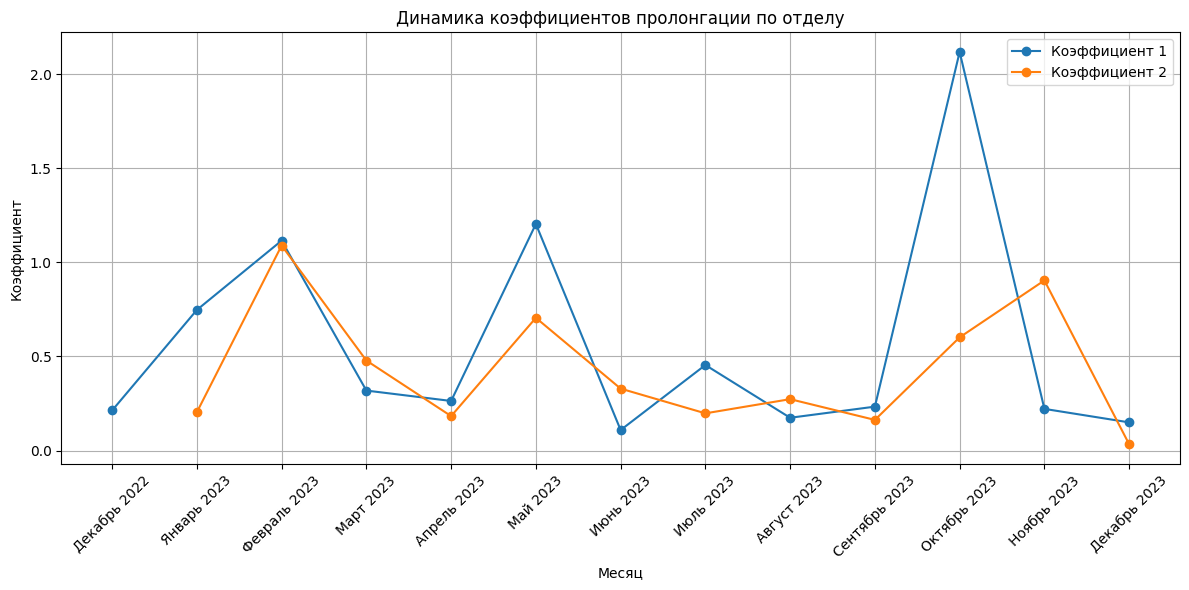

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    department_total['Месяц'],
    department_total['Коэффициент 1'],
    marker='o',
    label='Коэффициент 1'
)

plt.plot(
    department_total['Месяц'],
    department_total['Коэффициент 2'],
    marker='o',
    label='Коэффициент 2'
)

plt.title('Динамика коэффициентов пролонгации по отделу')
plt.xlabel('Месяц')
plt.ylabel('Коэффициент')

plt.xticks(rotation=45)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.show()

In [32]:
## Топ-5 менеджеров по коэффициенту пролонгации

#Графики показывают менеджеров с самым высоким средним коэффициентом пролонгации.

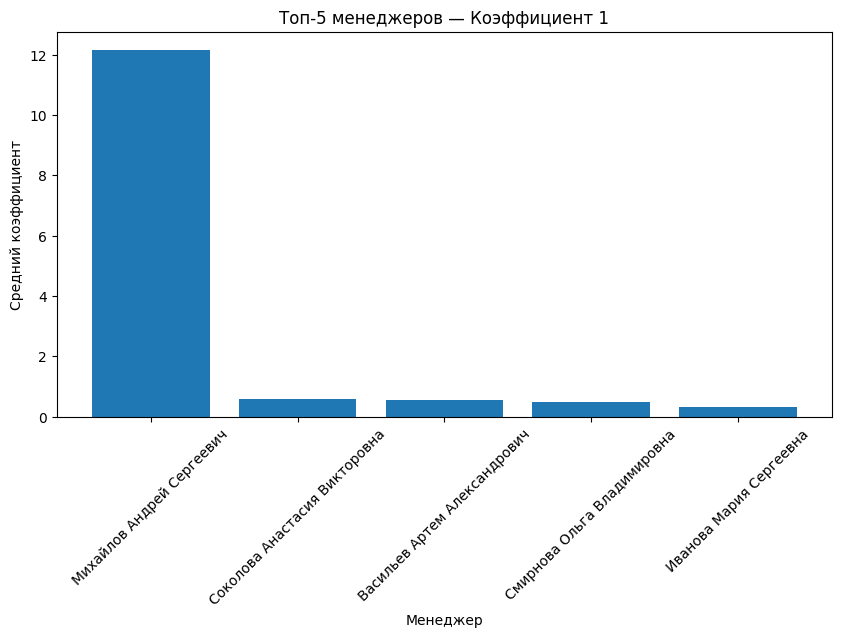

In [33]:
top_5_coef_1 = (
    manager_sum_coef_1
    .set_index('AM')
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 5))

plt.bar(top_5_coef_1.index, top_5_coef_1.values)

plt.title('Топ-5 менеджеров — Коэффициент 1')
plt.xlabel('Менеджер')
plt.ylabel('Средний коэффициент')

plt.xticks(rotation=45)

plt.show()

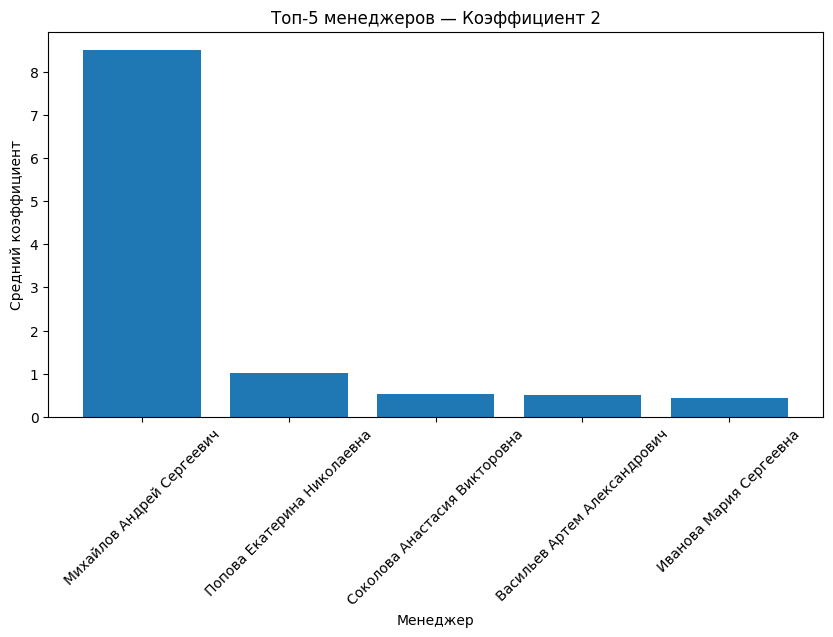

In [34]:
top_5_coef_2 = (
    manager_sum_coef_2
    .set_index('AM')
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(5)
)


plt.figure(figsize=(10, 5))

plt.bar(top_5_coef_2.index, top_5_coef_2.values)

plt.title('Топ-5 менеджеров — Коэффициент 2')
plt.xlabel('Менеджер')
plt.ylabel('Средний коэффициент')

plt.xticks(rotation=45)

plt.show()

In [ ]:
## Результат анализа

В результате анализа были рассчитаны коэффициенты пролонгации по отделу и каждому менеджеру.

Подготовлены аналитические таблицы и визуальные отчеты, которые могут использоваться для:
- оценки эффективности менеджеров;
- контроля динамики пролонгаций;
- выявления слабых мест в работе отдела;
- принятия управленческих решений.